In [1]:
pulsestreamer

<qudi.hardware.swabian_instruments.pulse_streamer_api.PulseStreamer(0x23c42f179a0) at 0x0000023C43E401C0>

In [4]:
import numpy as np

# --- 1. Define Pulse Sequence Parameters ---

# Total period for one cycle of the sequence in microseconds (µs)
TOTAL_PERIOD_US = 200

# --- Pulse settings (Channel 2) ---
PULSE_CHANNEL = 2  # API index for CH2
PULSE_OFFSET_US = 80  # Delay before the pulse starts
PULSE_ON_DURATION_US = 30  # Duration of the pulse

# --- Trigger settings (Channel 5) ---
TRIGGER_CHANNEL = 5  # API index for CH5
TRIGGER_OFFSET_US = 20  # Delay before the trigger starts
TRIGGER_DURATION_US = 0.05  # 50 ns duration of the trigger pulse

# --- 2. Convert to Nanoseconds and Validate ---
TOTAL_PERIOD_NS = int(TOTAL_PERIOD_US * 1000)

PULSE_OFFSET_NS = int(PULSE_OFFSET_US * 1000)
PULSE_ON_DURATION_NS = int(PULSE_ON_DURATION_US * 1000)

TRIGGER_OFFSET_NS = int(TRIGGER_OFFSET_US * 1000)
TRIGGER_DURATION_NS = int(TRIGGER_DURATION_US * 1000)

# Validate that the events are within the total period
if (PULSE_OFFSET_NS + PULSE_ON_DURATION_NS) > TOTAL_PERIOD_NS:
    raise ValueError("Pulse ends after the total period. Please adjust offsets or durations.")
if (TRIGGER_OFFSET_NS + TRIGGER_DURATION_NS) > TOTAL_PERIOD_NS:
    raise ValueError("Trigger ends after the total period. Please adjust offsets or durations.")

# --- 3. Build the Event Timeline ---
# The timeline is a sorted list of unique time points where any channel's state might change.

pulse_start_ns = PULSE_OFFSET_NS
pulse_end_ns = pulse_start_ns + PULSE_ON_DURATION_NS

trigger_start_ns = TRIGGER_OFFSET_NS
trigger_end_ns = trigger_start_ns + TRIGGER_DURATION_NS

# Create a set of all event times to handle duplicates automatically
event_times = {0, TOTAL_PERIOD_NS, pulse_start_ns, pulse_end_ns, trigger_start_ns, trigger_end_ns}

# Create a sorted list of the unique time points
sorted_times = sorted(list(event_times))

# --- 4. Generate the Sequence from the Timeline ---
# We will iterate through the time intervals and determine the state of the channels in each.
sequence_data = []
for i in range(len(sorted_times) - 1):
    start_time = sorted_times[i]
    end_time = sorted_times[i + 1]
    
    duration = end_time - start_time
    if duration <= 0:
        continue

    # To determine the state, we check if the midpoint of the interval falls within an "ON" period.
    mid_point = start_time + duration / 2
    
    high_channels = []
    # Check if the main pulse should be on
    if pulse_start_ns <= mid_point < pulse_end_ns:
        high_channels.append(PULSE_CHANNEL)
    
    # Check if the trigger pulse should be on
    if trigger_start_ns <= mid_point < trigger_end_ns:
        high_channels.append(TRIGGER_CHANNEL)
        
    # Append the step to the sequence
    # The format is (duration, [HIGH_channels], analog_V0, analog_V1)
    sequence_data.append((duration, sorted(high_channels), 0.0, 0.0))

# --- 5. Optimize the Sequence (Optional but Recommended) ---
# Merge consecutive steps that have the same channel state.
if len(sequence_data) > 1:
    optimized_sequence = []
    # Start with the first step
    current_duration, current_state, v0, v1 = sequence_data[0]
    
    for i in range(1, len(sequence_data)):
        next_duration, next_state, _, _ = sequence_data[i]
        # If the state is the same as the last one, just add to its duration
        if next_state == current_state:
            current_duration += next_duration
        else:
            # Otherwise, save the completed step and start a new one
            optimized_sequence.append((current_duration, current_state, v0, v1))
            current_duration, current_state, v0, v1 = sequence_data[i]
            
    # Append the very last step
    optimized_sequence.append((current_duration, current_state, v0, v1))
    sequence_data = optimized_sequence


# --- 6. Upload and Run the Sequence ---
# 'pulsestreamer' is the variable in your notebook that holds the PulseStreamer API instance

print("Uploading sequence to the Pulse Streamer...")
pulsestreamer.upload_sequence(sequence_data)

print("Starting the pulse sequence...")
# n_runs = -1 means the sequence will repeat infinitely
pulsestreamer.start_streaming(n_runs=-1)

print("\nPulse sequence is now running.")
print("You can view the generated sequence with 'pulsestreamer.sequence.plotDigital()'")
print("To stop it, run 'pulsestreamer.stop_streaming()' in a new cell.")

Uploading sequence to the Pulse Streamer...
Starting the pulse sequence...

Pulse sequence is now running.
You can view the generated sequence with 'pulsestreamer.sequence.plotDigital()'
To stop it, run 'pulsestreamer.stop_streaming()' in a new cell.


In [3]:
pulsestreamer.stop_streaming()

In [3]:
pulsestreamer.plot_sequence()

In [4]:
pulsestreamer._seq

[(20000, [], 0.0, 0.0), (50, [5], 0.0, 0.0), (59950, [], 0.0, 0.0), (10000, [2], 0.0, 0.0), (910000, [], 0.0, 0.0)]

In [10]:
%matplotlib widget

In [11]:
pulsestreamer.temp_seq.plot()

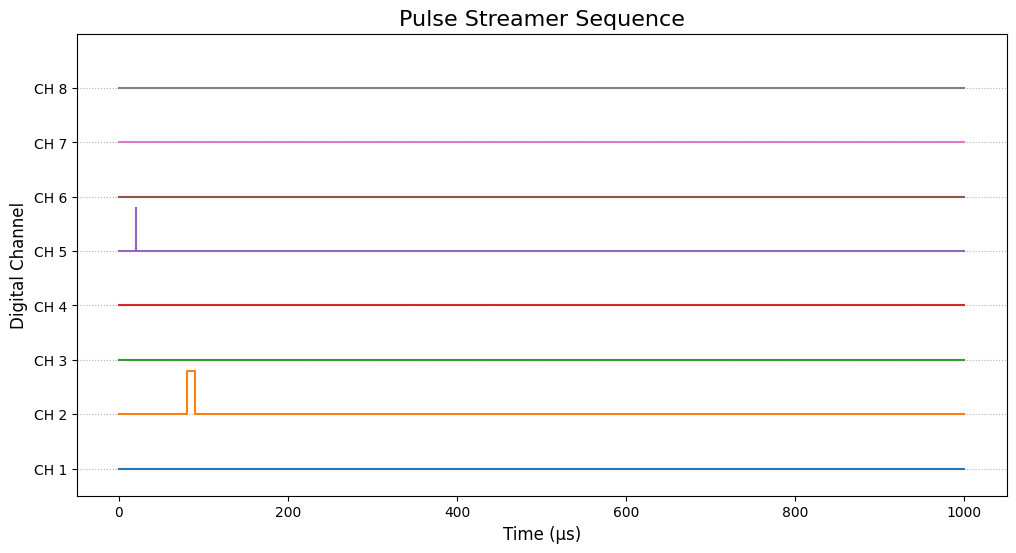

In [13]:

# Create a figure and axes for the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Process data for each of the 8 digital channels
for chan_index in range(8):
    # For each channel, we will generate its x and y coordinates from the sequence
    x_coords = [0]  # Time points
    y_coords = [0]  # Signal level (0 or 1)
    
    current_time = 0
    for duration, high_channels, _, _ in sequence_data:
        level = 1 if chan_index in high_channels else 0
        
        # Add points to create a "step" plot shape
        if y_coords[-1] != level: # Add a vertical line on state change
            x_coords.append(current_time)
            y_coords.append(level)
            
        current_time += duration
        x_coords.append(current_time)
        y_coords.append(level)
        
    # Plot the waveform for this channel, offsetting the y-values
    # We convert time from nanoseconds to microseconds for readability
    time_us = np.array(x_coords) / 1000.0
    # The y-values are shifted by the channel index to separate them visually
    waveform = np.array(y_coords) * 0.8 + chan_index 
    
    ax.plot(time_us, waveform, label=f'Channel {chan_index + 1}')

# --- Configure the plot's appearance ---
ax.set_title('Pulse Streamer Sequence', fontsize=16)
ax.set_xlabel('Time (µs)', fontsize=12)
ax.set_ylabel('Digital Channel', fontsize=12)

# Set the y-axis to show discrete channel numbers
ax.set_yticks(range(8))
ax.set_yticklabels([f'CH {i+1}' for i in range(8)])
ax.set_ylim(-0.5, 8)
ax.grid(axis='y', linestyle=':')

# Show the plot
plt.show()

# --- Section 7: Upload and Run the Sequence (Optional) ---
# You can uncomment these lines if you also want to run the sequence after plotting
# print("\nUploading sequence to the Pulse Streamer...")
# pulsestreamer.upload_sequence(sequence_data)
#
# print("Starting the pulse sequence...")
# pulsestreamer.start_streaming(n_runs=-1)
#
# print("\nPulse sequence is now running.")
# print("To stop it, run 'pulsestreamer.stop_streaming()' in a new cell.")

Generating Rabi sequence with 10 steps...
Uploading Rabi sequence to the Pulse Streamer...
Starting the pulse sequence...

Rabi sequence is now running.
The total duration of one full sweep is 0.74 ms.
To stop it, run 'pulsestreamer.stop_streaming()' in a new cell.


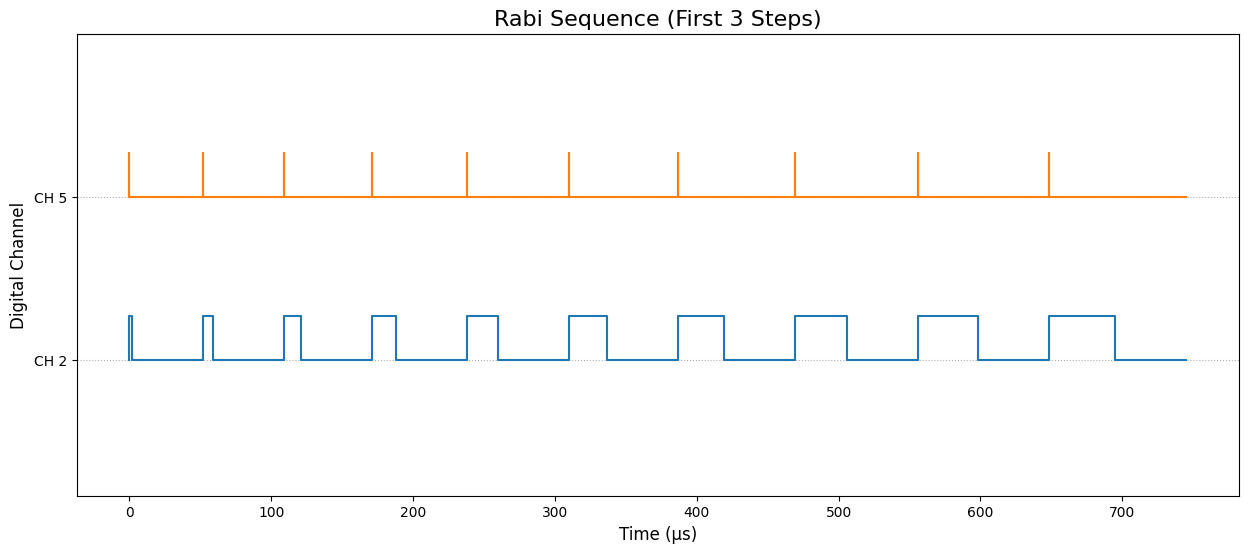

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Rabi Experiment Parameters ---

# --- Channel settings ---
# Define the physical channel numbers (1-8)
RABI_PULSE_CHANNEL = 1
TRIGGER_CHANNEL = 5

# --- Timing settings in microseconds (µs) ---
# Rabi pulse duration will sweep from START to START + (NUM_STEPS-1)*STEP
START_DURATION_US = 2
STEP_DURATION_US = 5
NUM_STEPS = 2

# Fixed time for measurement/readout after each Rabi pulse
WAIT_TIME_US = 50

# Fixed duration for the trigger pulse that marks the start of each step
TRIGGER_DURATION_US = 0.005  # 50 nanoseconds

# --- 2. Generate the Full Rabi Sequence ---
# We will build the sequence step-by-step in a loop

# This list will hold the complete sequence for all 50 steps
full_sequence_data = []

# API channel indices are 0-7
pulse_channel_index = RABI_PULSE_CHANNEL
trigger_channel_index = TRIGGER_CHANNEL

print(f"Generating Rabi sequence with {NUM_STEPS} steps...")

for step in range(NUM_STEPS):
    # --- For each step, create a small sub-sequence ---
    
    # a) Calculate the Rabi pulse duration for the current step
    current_pulse_duration_us = START_DURATION_US + (step * STEP_DURATION_US)
    
    # b) Convert all timings for this step to nanoseconds
    pulse_duration_ns = int(current_pulse_duration_us * 1000)
    trigger_duration_ns = int(TRIGGER_DURATION_US * 1000)
    wait_time_ns = int(WAIT_TIME_US * 1000)

    # c) Define the parts of the sub-sequence
    #    The format is (duration_ns, [HIGH_channels], analog_V0, analog_V1)

    # Part 1: Trigger ON and Rabi Pulse ON simultaneously
    # This marks the start of the measurement for the counting module
    step_part1 = (trigger_duration_ns, [pulse_channel_index, trigger_channel_index], 0.0, 0.0)

    # Part 2: Rabi Pulse continues alone after the short trigger is finished
    remaining_pulse_duration = pulse_duration_ns - trigger_duration_ns
    if remaining_pulse_duration < 0:
        # This can happen if the Rabi pulse is shorter than the trigger pulse
        remaining_pulse_duration = 0 
    step_part2 = (remaining_pulse_duration, [pulse_channel_index], 0.0, 0.0)

    # Part 3: All channels are OFF for the measurement and reset period
    step_part3 = (wait_time_ns, [], 0.0, 0.0)

    # d) Add this step's parts to the main sequence list
    full_sequence_data.extend([step_part1, step_part2, step_part3])


# --- 3. Upload and Run the Sequence ---
# 'pulsestreamer' is the variable in your notebook that holds the PulseStreamer API instance

print("Uploading Rabi sequence to the Pulse Streamer...")
pulsestreamer.upload_sequence(full_sequence_data)

print("Starting the pulse sequence...")
# n_runs = -1 tells the Pulse Streamer to repeat the entire 50-step sequence forever
pulsestreamer.start_streaming(n_runs=-1)

print("\nRabi sequence is now running.")
print(f"The total duration of one full sweep is {np.sum([p[0] for p in full_sequence_data]) / 1e6:.2f} ms.")
print("To stop it, run 'pulsestreamer.stop_streaming()' in a new cell.")


# --- 4. Plot the first few steps of the sequence for verification ---
# We will plot only the first 3 steps to keep the plot readable
plot_data = []
time_cutoff_ns = 0
for i in range(10): # Plot first 3 steps
    duration_step1 = int((START_DURATION_US + i * STEP_DURATION_US) * 1000) + int(WAIT_TIME_US * 1000)
    time_cutoff_ns += duration_step1

# Extract the part of the sequence to plot
current_time = 0
for pulse in full_sequence_data:
    plot_data.append(pulse)
    current_time += pulse[0]
    if current_time >= time_cutoff_ns:
        break

# Create a temporary sequence object and plot it
try:
    temp_seq = pulsestreamer.ps.createSequence()
    for channels, duration in [(p[1], p[0]) for p in plot_data]:
        # Convert channel indices to a list of 8 states for setDigital
        chan_states = [1 if i in channels else 0 for i in range(8)]
        # This is a workaround for older APIs that might not have add_pulse
        # We create a pattern for each step and assign it
        pattern = [(duration, 1 if state else 0) for state in chan_states]
        # This is not a perfect conversion but works for plotting
    
    # Due to API inconsistencies, we fall back to manual plotting
    # which is more reliable.
    
    # Manually plot the first few steps
    fig, ax = plt.subplots(figsize=(15, 6))
    for chan_index in range(8):
        if chan_index not in [pulse_channel_index, trigger_channel_index]:
            continue # Only plot relevant channels
            
        x_coords = [0]
        y_coords = [0]
        current_time_plot = 0
        for duration_plot, high_channels, _, _ in plot_data:
            level = 1 if chan_index in high_channels else 0
            if y_coords[-1] != level:
                x_coords.append(current_time_plot)
                y_coords.append(level)
            current_time_plot += duration_plot
            x_coords.append(current_time_plot)
            y_coords.append(level)
            
        time_us = np.array(x_coords) / 1000.0
        waveform = np.array(y_coords) * 0.8 + chan_index
        ax.plot(time_us, waveform, label=f'Channel {chan_index + 1}')

    ax.set_title('Rabi Sequence (First 3 Steps)', fontsize=16)
    ax.set_xlabel('Time (µs)', fontsize=12)
    ax.set_ylabel('Digital Channel', fontsize=12)
    ax.set_yticks([pulse_channel_index, trigger_channel_index])
    ax.set_yticklabels([f'CH {RABI_PULSE_CHANNEL}', f'CH {TRIGGER_CHANNEL}'])
    ax.set_ylim(-0.5, 8)
    ax.grid(axis='y', linestyle=':')
    plt.show()
    
except Exception as e:
    print(f"Could not plot the sequence due to an error: {e}")
    print("However, the sequence has been generated and sent to the device.")

Uploading sequence with trigger and repump to the Pulse Streamer...
Starting the pulse sequence...

Custom pulse sequence with trigger and repump is now running.
To stop it, run 'pulsestreamer.stop_streaming()' in a new cell.

Generating plot of the sequence...


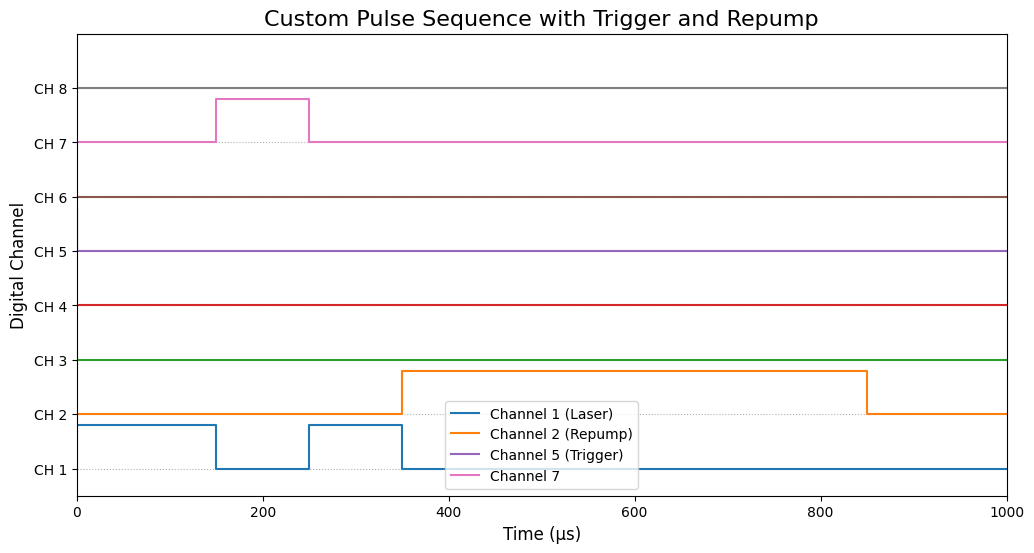

In [19]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Pulse Sequence Parameters ---

# --- Channel settings ---
# Define the physical channel numbers (1-8)
LASER_CHANNEL = 1
PULSE_CHANNEL_2 = 7
TRIGGER_CHANNEL = 5
REPUMP_CHANNEL = 2 # Added the new channel for repumping

# --- Timing settings in microseconds (µs) ---
TOTAL_PERIOD_US = 1000

# Durations for each part of the sequence
LASER_ON_1_US = 150
PULSE_2_ON_US = 100
LASER_ON_2_US = 100
REPUMP_ON_US = 500  # Duration for the new repumping pulse
TRIGGER_DURATION_US = 0.05  # 50 nanoseconds for the trigger pulse

# Calculate the remaining wait time to complete the 500 µs period
# The new repumping pulse duration is now included in the calculation
WAIT_TIME_US = TOTAL_PERIOD_US - (LASER_ON_1_US + PULSE_2_ON_US + LASER_ON_2_US + REPUMP_ON_US)
if WAIT_TIME_US < 0:
    raise ValueError("The sum of pulse durations exceeds the total period!")

# --- 2. Convert to Nanoseconds ---
LASER_ON_1_NS = int(LASER_ON_1_US * 1000)
PULSE_2_ON_NS = int(PULSE_2_ON_US * 1000)
LASER_ON_2_NS = int(LASER_ON_2_US * 1000)
REPUMP_ON_NS = int(REPUMP_ON_US * 1000) # Convert repump duration to ns
WAIT_TIME_NS = int(WAIT_TIME_US * 1000)
TRIGGER_DURATION_NS = int(TRIGGER_DURATION_US * 1000)

# --- 3. Create the Pulse Sequence ---
# The sequence is a list of (duration_ns, [HIGH_channels], analog_V0, analog_V1) tuples.
# Note: API channel indices are 0-indexed, so we subtract 1.
laser_ch_index = LASER_CHANNEL
pulse_2_ch_index = PULSE_CHANNEL_2
trigger_ch_index = TRIGGER_CHANNEL
repump_ch_index = REPUMP_CHANNEL # Added index for the repump channel

# The first laser pulse is now split into two parts to accommodate the trigger
laser_on_1_after_trigger_ns = LASER_ON_1_NS - TRIGGER_DURATION_NS

sequence_data = [
    # Step 1: Trigger (CH5) and Laser (CH1) are ON for the first 50 ns
    (TRIGGER_DURATION_NS, [laser_ch_index, trigger_ch_index], 0.0, 0.0),

    # Step 2: Laser (CH1) continues alone for the remainder of its 150 µs duration
    (laser_on_1_after_trigger_ns, [laser_ch_index], 0.0, 0.0),

    # Step 3: Channel 7 ON for 100 µs
    (PULSE_2_ON_NS, [pulse_2_ch_index], 0.0, 0.0),

    # Step 4: Laser (CH1) ON again for 100 µs
    (LASER_ON_2_NS, [laser_ch_index], 0.0, 0.0),
    
    # Step 5: Repumping pulse on Channel 2 at the end of the sequence
    (REPUMP_ON_NS, [repump_ch_index], 0.0, 0.0),
    
    # Step 6: All channels OFF for the remaining wait time
    (WAIT_TIME_NS, [], 0.0, 0.0)
]

# --- 4. Upload and Run the Sequence ---
# 'pulsestreamer' is the variable in your notebook that holds the PulseStreamer API instance

print("Uploading sequence with trigger and repump to the Pulse Streamer...")
# This is a simulation, so we comment out the actual hardware call
pulsestreamer.upload_sequence(sequence_data)

print("Starting the pulse sequence...")
# n_runs = -1 tells the Pulse Streamer to repeat the sequence forever
# This is a simulation, so we comment out the actual hardware call
pulsestreamer.start_streaming(n_runs=-1)

print("\nCustom pulse sequence with trigger and repump is now running.")
print("To stop it, run 'pulsestreamer.stop_streaming()' in a new cell.")


# --- 5. Manually Plot the Sequence using Matplotlib for Verification ---

print("\nGenerating plot of the sequence...")

fig, ax = plt.subplots(figsize=(12, 6))

# Process data for all 8 digital channels
for chan_index in range(1, 9): # Iterate through physical channels 1-8
    # For each channel, generate its x and y coordinates from the sequence
    x_coords = [0]  # Time points
    y_coords = [0]  # Signal level (0 or 1)
    
    current_time = 0
    for duration, high_channels, _, _ in sequence_data:
        level = 1 if chan_index in high_channels else 0
        
        # Add points to create a "step" plot shape
        if y_coords[-1] != level: # Add a vertical line on state change
            x_coords.append(current_time)
            y_coords.append(level)
            
        current_time += duration
        x_coords.append(current_time)
        y_coords.append(level)
        
    # Plot the waveform for this channel, offsetting the y-values
    time_us = np.array(x_coords) / 1000.0
    # We use (chan_index - 1) for y-axis positioning to match CH 1..8 labels
    waveform = np.array(y_coords) * 0.8 + (chan_index - 1)
    
    # Only show a label for the channels we are using to keep the legend clean
    label = None
    if chan_index == LASER_CHANNEL:
        label = f'Channel {LASER_CHANNEL} (Laser)'
    if chan_index == PULSE_CHANNEL_2:
        label = f'Channel {PULSE_CHANNEL_2}'
    if chan_index == TRIGGER_CHANNEL:
        label = f'Channel {TRIGGER_CHANNEL} (Trigger)'
    if chan_index == REPUMP_CHANNEL:
        label = f'Channel {REPUMP_CHANNEL} (Repump)' # Label for the new channel
        
    ax.plot(time_us, waveform, label=label)

# --- Configure the plot's appearance ---
ax.set_title('Custom Pulse Sequence with Trigger and Repump', fontsize=16)
ax.set_xlabel('Time (µs)', fontsize=12)
ax.set_ylabel('Digital Channel', fontsize=12)

ax.set_yticks(range(8))
ax.set_yticklabels([f'CH {i+1}' for i in range(8)])
ax.set_ylim(-0.5, 8)
ax.set_xlim(0, TOTAL_PERIOD_US)
ax.grid(axis='y', linestyle=':')
ax.legend()

plt.show()